# 05 — LLM-Pipeline 2: Visualisierungen → natürlichsprachliche Erklärung

**Idee:** Das LLM erhält **Waterfall-Plots** der SHAP-/EBM-Beiträge als Bild
und erklärt, was es sieht — ohne strukturierte JSON-Daten.

- **Vorteil:** Nutzt visuelle Mustererkennung; näher an menschlicher Intuition.
- **Nachteil:** Präzise Zahlenwerte gehen im Bild verloren.

**Ablauf:**
1. Plots generieren und in `explanations/plots/` speichern (kein API-Key nötig)
2. Plots + Kontext-Prompt an Claude senden
3. Ergebnisse in `results/pipeline05/` speichern

In [1]:
from __future__ import annotations

import sys, json, time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import joblib
import shap

from utils import INSTANCE_IDS, EXPLANATIONS_DIR, RESULTS_DIR, MODELS_DIR, PROMPTS_DIR
from utils.data import load_train_test
from utils.llm import ask_with_images, DEFAULT_MODEL

LOSS_KEY  = 'poisson_log'
MODEL     = DEFAULT_MODEL
MAX_TOKENS = 600
PLOTS_DIR = EXPLANATIONS_DIR / 'plots'
OUT_DIR   = RESULTS_DIR / 'pipeline05'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'LLM-Modell:    {MODEL}')
print(f'Plots-Ausgabe: {PLOTS_DIR}')
print(f'Ergebnisse:    {OUT_DIR}')

LLM-Modell:    claude-sonnet-4-6
Plots-Ausgabe: /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation_1205/explanations/plots
Ergebnisse:    /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation_1205/results/pipeline05


## 1 · Daten und Modelle laden

In [2]:
X_train, y_train, X_test, y_test = load_train_test()
xgb = joblib.load(MODELS_DIR / f'xgb_{LOSS_KEY}.pkl')
ebm = joblib.load(MODELS_DIR / f'ebm_{LOSS_KEY}.pkl')

# SHAP TreeExplainer einmal initialisieren (teuer)
shap_explainer = shap.TreeExplainer(xgb)
shap_values    = shap_explainer(X_test)

print('Modelle und SHAP-Werte geladen.')
print(f'X_test shape: {X_test.shape}')

Modelle und SHAP-Werte geladen.
X_test shape: (5214, 9)


## 2 · Plot-Generierung

Für jede Instanz und jedes Modell wird ein Waterfall-Plot erzeugt:
- **XGBoost**: `shap.plots.waterfall` (eingebaut)
- **EBM**: Matplotlib-Balkendiagramm (interpret nutzt Plotly, nicht Matplotlib)

In [3]:
def plot_xgb_waterfall(instance_id: int) -> Path:
    """SHAP Waterfall-Plot für XGBoost, gespeichert als PNG."""
    # Positionsindex im X_test-DataFrame
    pos = list(X_test.index).index(instance_id)
    pred = float(xgb.predict(X_test.iloc[[pos]])[0])
    y    = float(y_test.iloc[pos])

    fig, ax = plt.subplots(figsize=(8, 5))
    shap.plots.waterfall(shap_values[pos], show=False, max_display=10)
    plt.title(f'XGBoost – Instanz {instance_id} | '
              f'Vorhersage: {pred:.1f}  (tatsächlich: {y:.0f})', pad=12)
    path = PLOTS_DIR / f'waterfall_xgb_{LOSS_KEY}_inst{instance_id}.png'
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.close('all')
    return path


def plot_ebm_waterfall(instance_id: int) -> Path:
    """Manueller Waterfall-Plot für EBM-Beiträge."""
    pos  = list(X_test.index).index(instance_id)
    inst = X_test.iloc[[pos]]
    pred = float(ebm.predict(inst)[0])
    y    = float(y_test.iloc[pos])

    exp  = ebm.explain_local(inst)
    d    = exp.data(0)
    base = float(d['extra']['scores'][0])  # Intercept

    # Nur Haupteffekte (keine Interaktionen), Top-10 nach |score|
    pairs = [(n, float(s)) for n, s in zip(d['names'], d['scores'])]
    pairs = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)[:10]
    labels = [p[0] for p in pairs]
    scores = [p[1] for p in pairs]
    colors = ['#d73027' if v > 0 else '#4575b4' for v in scores]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1], height=0.65)
    ax.axvline(0, color='black', lw=0.8)
    for bar, val in zip(bars, scores[::-1]):
        ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
    ax.set_xlabel('Beitrag (Log-Skala)', fontsize=10)
    ax.set_title(f'EBM – Instanz {instance_id} | '
                 f'Vorhersage: {pred:.1f}  (tatsächlich: {y:.0f})\n'
                 f'Basiswert (Intercept): {base:.3f}', fontsize=11, pad=12)
    plt.tight_layout()
    path = PLOTS_DIR / f'waterfall_ebm_{LOSS_KEY}_inst{instance_id}.png'
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.close('all')
    return path

In [4]:
plot_paths: dict[tuple, Path] = {}

for iid in INSTANCE_IDS:
    p_xgb = plot_xgb_waterfall(iid)
    p_ebm = plot_ebm_waterfall(iid)
    plot_paths[('xgb', iid)] = p_xgb
    plot_paths[('ebm', iid)] = p_ebm
    print(f'  inst={iid:4d}  -> {p_xgb.name}')
    print(f'         -> {p_ebm.name}')

print(f'\n{len(plot_paths)} Plots gespeichert in {PLOTS_DIR}')

  inst= 224  -> waterfall_xgb_poisson_log_inst224.png
         -> waterfall_ebm_poisson_log_inst224.png
  inst= 580  -> waterfall_xgb_poisson_log_inst580.png
         -> waterfall_ebm_poisson_log_inst580.png
  inst=1041  -> waterfall_xgb_poisson_log_inst1041.png
         -> waterfall_ebm_poisson_log_inst1041.png
  inst=1481  -> waterfall_xgb_poisson_log_inst1481.png
         -> waterfall_ebm_poisson_log_inst1481.png
  inst=1677  -> waterfall_xgb_poisson_log_inst1677.png
         -> waterfall_ebm_poisson_log_inst1677.png
  inst=2058  -> waterfall_xgb_poisson_log_inst2058.png
         -> waterfall_ebm_poisson_log_inst2058.png
  inst=2510  -> waterfall_xgb_poisson_log_inst2510.png
         -> waterfall_ebm_poisson_log_inst2510.png
  inst=3543  -> waterfall_xgb_poisson_log_inst3543.png
         -> waterfall_ebm_poisson_log_inst3543.png
  inst=3847  -> waterfall_xgb_poisson_log_inst3847.png
         -> waterfall_ebm_poisson_log_inst3847.png
  inst=4454  -> waterfall_xgb_poisson_log_inst4454

## 3 · Beispielplots anzeigen

XGB – Instanz 224:


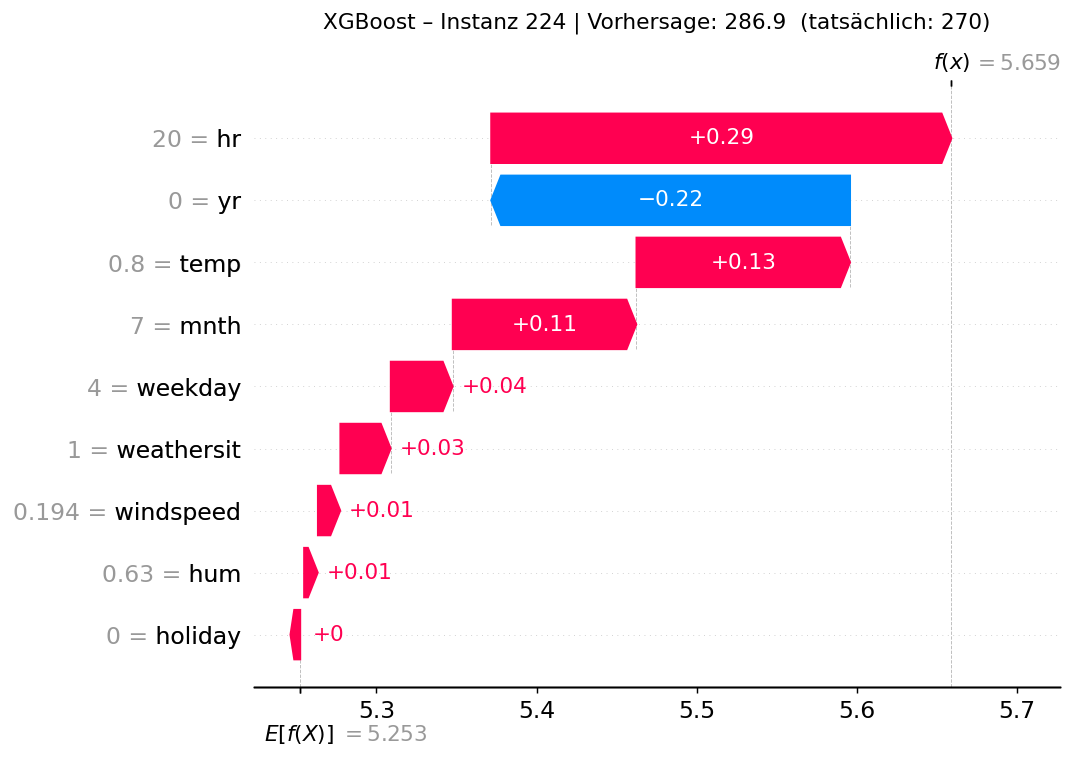


EBM – Instanz 224:


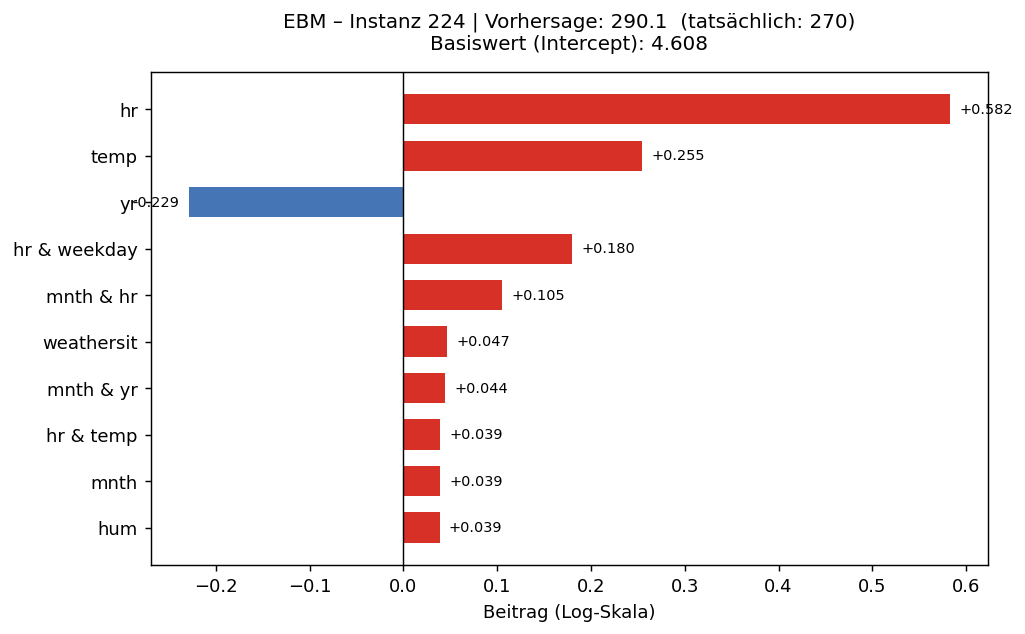

In [5]:
from IPython.display import display, Image as IPImage

for model_name in ['xgb', 'ebm']:
    iid = INSTANCE_IDS[0]
    print(f'{model_name.upper()} – Instanz {iid}:')
    display(IPImage(filename=str(plot_paths[(model_name, iid)]), width=620))
    print()

## 4 · System-Prompt

In [6]:
SYSTEM_PROMPT = (PROMPTS_DIR / "pipeline_05_vision.md").read_text()

print(f'System-Prompt: {len(SYSTEM_PROMPT)} Zeichen, ~{len(SYSTEM_PROMPT)//4} Tokens (geschätzt)')

System-Prompt: 2401 Zeichen, ~600 Tokens (geschätzt)


## 5 · LLM-Aufrufe mit Plots

> **Voraussetzung:** `ANTHROPIC_API_KEY` in `.env` oder als Umgebungsvariable.

In [7]:
WEEKDAYS_LONG = ["Sonntag", "Montag", "Dienstag", "Mittwoch",
                 "Donnerstag", "Freitag", "Samstag"]
MONTHS_LONG   = ["", "Januar", "Februar", "März", "April", "Mai", "Juni",
                 "Juli", "August", "September", "Oktober", "November", "Dezember"]
WEATHER_LONG  = {1: "klar/wenige Wolken", 2: "Nebel/bewölkt",
                 3: "leichter Regen/Schnee", 4: "Starkregen/Gewitter"}


def build_context_prompt(model_name: str, instance_id: int) -> str:
    """Kontexttext zum Plot — lesbare Merkmalswerte aus JSON-Erklärung."""
    local_path = EXPLANATIONS_DIR / f'local_{model_name}_{LOSS_KEY}_inst{instance_id}.json'
    l = json.loads(local_path.read_text())
    fv = l["feature_values"]

    lines = [
        f"Modell: {model_name.upper()}",
        f"Instanz-ID: {instance_id}",
        f"Uhrzeit: {int(fv['hr']):02d}:00 Uhr",
        f"Wochentag: {WEEKDAYS_LONG[int(fv['weekday'])]}",
        f"Monat: {MONTHS_LONG[int(fv['mnth'])]}",
        f"Jahr: {'2011' if int(fv['yr']) == 0 else '2012'}",
        f"Wetter: {WEATHER_LONG.get(int(fv['weathersit']), fv['weathersit'])}",
        f"Temperatur: ~{float(fv['temp']) * 41:.1f} °C (normalisiert: {float(fv['temp']):.2f})",
        f"Luftfeuchtigkeit: {float(fv['hum']) * 100:.0f} %",
        f"Windgeschwindigkeit: {float(fv['windspeed']) * 67:.1f} km/h",
        f"Feiertag: {'ja' if int(fv['holiday']) == 1 else 'nein'}",
        f"Tatsächliche Ausleihe: {int(l['y_true'])} Fahrräder",
        f"Modellvorhersage: {l['prediction']:.1f} Fahrräder",
        "",
        "Bitte erkläre den Waterfall-Plot oben für diese Situation.",
    ]
    return "\n".join(lines)


results = []
total_in, total_out, total_cache = 0, 0, 0

for model_name in ["xgb", "ebm"]:
    for iid in INSTANCE_IDS:
        prompt = build_context_prompt(model_name, iid)
        plot_path = plot_paths[(model_name, iid)]

        t0 = time.time()
        response = ask_with_images(
            prompt,
            image_paths=[plot_path],
            system=SYSTEM_PROMPT,
            model=MODEL,
            max_tokens=MAX_TOKENS,
            cache_system=True,
        )
        elapsed = time.time() - t0

        text    = response["content"][0]["text"]
        usage   = response.get("usage", {})
        in_tok  = usage.get("input_tokens", 0)
        out_tok = usage.get("output_tokens", 0)
        cache_r = usage.get("cache_read_input_tokens", 0)
        total_in += in_tok; total_out += out_tok; total_cache += cache_r

        local_path = EXPLANATIONS_DIR / f"local_{model_name}_{LOSS_KEY}_inst{iid}.json"
        l = json.loads(local_path.read_text())

        record = {
            "pipeline":    "05_vision",
            "llm_model":   MODEL,
            "loss_key":    LOSS_KEY,
            "xai_model":   model_name,
            "instance_id": iid,
            "explanation": text,
            "plot_file":   plot_path.name,
            "elapsed_s":   round(elapsed, 2),
            "usage":       {"input_tokens": in_tok, "output_tokens": out_tok,
                            "cache_read_input_tokens": cache_r},
            "prediction":  l["prediction"],
            "y_true":      l["y_true"],
        }
        results.append(record)
        (OUT_DIR / f"{model_name}_inst{iid}.json").write_text(
            json.dumps(record, indent=2, ensure_ascii=False)
        )
        print(f"  {model_name.upper()} inst={iid:4d}  "
              f"pred={l['prediction']:6.1f}  y={l['y_true']:5.0f}  "
              f"in={in_tok}  out={out_tok}  cache={cache_r}  t={elapsed:.1f}s")

print(f"\nGesamt:  input={total_in}  output={total_out}  cache_gelesen={total_cache}")


  XGB inst= 224  pred= 286.9  y=  270  in=2309  out=499  cache=0  t=12.8s
  XGB inst= 580  pred=  12.1  y=    5  in=2308  out=495  cache=0  t=12.4s
  XGB inst=1041  pred= 208.2  y=  229  in=2309  out=491  cache=0  t=11.8s
  XGB inst=1481  pred= 108.3  y=  113  in=2310  out=526  cache=0  t=11.9s
  XGB inst=1677  pred= 180.3  y=  145  in=2310  out=533  cache=0  t=13.8s
  XGB inst=2058  pred= 179.5  y=  238  in=2309  out=497  cache=0  t=12.8s
  XGB inst=2510  pred= 368.9  y=  337  in=2310  out=516  cache=0  t=12.4s
  XGB inst=3543  pred= 660.0  y=  691  in=2310  out=495  cache=0  t=12.4s
  XGB inst=3847  pred= 141.4  y=  122  in=2253  out=526  cache=0  t=12.2s
  XGB inst=4454  pred= 382.3  y=  311  in=2310  out=522  cache=0  t=12.0s
  EBM inst= 224  pred= 290.1  y=  270  in=2069  out=515  cache=0  t=12.9s
  EBM inst= 580  pred=   9.7  y=    5  in=2068  out=533  cache=0  t=12.2s
  EBM inst=1041  pred= 221.3  y=  229  in=2069  out=500  cache=0  t=12.1s
  EBM inst=1481  pred= 124.9  y=  113 

## 6 · Beispiel-Erklärungen

In [8]:
for rec in results[:2]:
    sep = '=' * 70
    print(sep)
    print(f"Modell: {rec['xai_model'].upper()}  |  Instanz: {rec['instance_id']}  "
          f"|  Plot: {rec['plot_file']}")
    print(f"Vorhersage: {rec['prediction']:.1f}  |  Tatsächlich: {rec['y_true']:.0f}")
    print(sep)
    print(rec['explanation'])
    print()

Modell: XGB  |  Instanz: 224  |  Plot: waterfall_xgb_poisson_log_inst224.png
Vorhersage: 286.9  |  Tatsächlich: 270
Das Modell sagt für diese Stunde 286,9 ausgeliehene Fahrräder vorher, während tatsächlich 270 Räder ausgeliehen wurden. Die Abweichung beträgt knapp 17 Fahrräder, was einer Genauigkeit von etwa 94 % entspricht — das ist eine gute Vorhersage, die den realen Wert sehr nah trifft.

Den größten Auftrieb gibt die Uhrzeit 20:00 Uhr: Der Abend nach Feierabend ist noch eine aktive Phase, in der viele Menschen Fahrräder für den Heimweg oder Freizeitausflüge nutzen. Dieser Faktor erhöht die Vorhersage am stärksten. Deutlich gegenwirkend ist das Jahr 2011 (yr = 0): Da das Bikeshare-System damals noch relativ neu und weniger bekannt war, liegt die erwartete Nachfrage strukturell niedriger als in späteren Jahren — dieser Balken zieht die Vorhersage merklich nach unten. Als dritter wichtiger Treiber wirkt die angenehm warme Temperatur von rund 33 °C positiv: Solche Sommerwärme lädt zum

## 7 · Zusammenfassung

In [9]:
import pandas as pd

summary = pd.DataFrame([
    {
        'Modell':     r['xai_model'].upper(),
        'Instanz':    r['instance_id'],
        'y_true':     r['y_true'],
        'Vorhersage': r['prediction'],
        'Wörter':     len(r['explanation'].split()),
        'tok_input':  r['usage']['input_tokens'],
        'tok_output': r['usage']['output_tokens'],
        'Zeit (s)':   r['elapsed_s'],
    }
    for r in results
])
display(summary)

,Modell,Instanz,y_true,Vorhersage,Wörter,tok_input,tok_output,Zeit (s)
0,XGB,224,270.0,286.8653,200,2309,499,12.83
1,XGB,580,5.0,12.1144,209,2308,495,12.37
2,XGB,1041,229.0,208.2260,203,2309,491,11.76
3,XGB,1481,113.0,108.3289,225,2310,526,11.89
4,XGB,1677,145.0,180.2743,211,2310,533,13.84
5,XGB,2058,238.0,179.4730,198,2309,497,12.84
6,XGB,2510,337.0,368.9001,208,2310,516,12.43
7,XGB,3543,691.0,660.0004,202,2310,495,12.39
8,XGB,3847,122.0,141.3505,214,2253,526,12.17
9,XGB,4454,311.0,382.2661,213,2310,522,11.99
